In [ ]:
""" 
This code will create a false color image from James Webb Space Telescope observations using the MIRI instrument. It does this through pulling data from the Mast API and processing the resulting data. These observations will be displayed and will be stacked to make a RGB false color image. This is done by assigning a red, green, and blue to a long, medium, and short wavelength of light see through the MIRI wavelength filters. This notebook pulls the data from the API and displays the raw images while the next notebook, False_color, creates a pretty false color image.
"""
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astroquery.mast import Observations
import os
import glob
from astropy.table import vstack
import json
import re as _re
'''
This is where you input the target that you want to observe
This is the only variable that needs to be changed to make a new false color image
Not all objects have miri observations and not all objects have the filters that we want to pull
The code will correct for this and will handle if there is no available observations 
'''
target_name = "NGC 5195"

'''
We will later on download the data to an individual folder with the same name as target_name. This here searches through the files on your computer to see if there is a file in the directory with the _i2d.fits name. If there is a file, it then skips pulling the API saving computing time and preventing from downloading the same files twice.
'''
fits_dir = f"./fits_images/{target_name}"
_skip_query = False
if os.path.isdir(fits_dir):
    existing = glob.glob(os.path.join(fits_dir, "*_i2d.fits"))
    if existing:
        print(f"Found {len(existing)} FITS file(s) on disk in {fits_dir} — skipping MAST query.")
        for p in sorted(existing):
            print(f"  {os.path.basename(p)}")
        _skip_query = True
'''
If the observation has not been downloaded yet, it continues and will talk to the API. It does an object based query of the defined target in a radius of .1 degrees around the target to prevent pulling too much data. It will then filter the returned data to make sure it is a MIRI image, has the right data type, comes from JWST, and is public data. It then prints the output of the query.
'''
if not _skip_query:
    obs = Observations.query_object(target_name, radius="0.1 deg")

    miri_obs = obs[
        (obs['instrument_name'] == 'MIRI/IMAGE') &
        (obs['dataproduct_type'] == 'image') &
        (obs['obs_collection'] == 'JWST') &
        (obs['dataRights'] == 'PUBLIC')
    ]
    print(f"MAST query returned {len(miri_obs)} MIRI/IMAGE observations.")
    print (miri_obs)


MAST query returned 65 MIRI/IMAGE observations.
intentType obs_collection provenance_name ... wave_max      distance     
---------- -------------- --------------- ... -------- ------------------
   science           JWST             APT ...   8800.0                0.0
   science           JWST             APT ...   8800.0                0.0
   science           JWST             APT ...   8800.0                0.0
   science           JWST             APT ...   8800.0                0.0
   science           JWST             APT ...  11000.0                0.0
   science           JWST             APT ...  11000.0                0.0
   science           JWST             APT ...  11000.0                0.0
   science           JWST             APT ...  11000.0                0.0
   science           JWST             APT ...  11650.0                0.0
   science           JWST             APT ...  11650.0                0.0
       ...            ...             ... ...      ...          

In [ ]:
'''
We next define what filters we want to look at. MIRI has several filters, we choose one that is at a short medium and long wavelength. These will be the filters that will be assigned to blue green and red respectably later.
'''
target_filters = ['F770W', 'F1500W', 'F2550W']
'''
We again check to see if the data has been downloaded to prevent any errors. If the observation has not been downloaded it will print out all the observations with the filters that we want to use. 
'''
if _skip_query:
    # Already have files on disk — detect which filters are available
    for f in target_filters:
        matches = [p for p in existing if f"_f{f[1:].lower()}" in os.path.basename(p).lower()]
        status = "found on disk" if matches else "MISSING"
        print(f"  {f}: {status}")
    print("\nSkipped MAST filter step — using local files.")
else:
    filtered_by_filter = {}
    for f in target_filters:
        filtered_by_filter[f] = miri_obs[miri_obs['filters'] == f]

    for f, data in filtered_by_filter.items():
        print(f"\n=== Filter: {f} ===")
        print(f"Count: {len(data)}")
        for row in data:
            print(f"  obs_id: {row['obs_id']} | filters: {row['filters']} | t_exptime: {row['t_exptime']}")
    all_filtered = vstack([filtered_by_filter[f] for f in target_filters if len(filtered_by_filter[f]) > 0])
    print(f"\nTotal across all 3 filters: {len(all_filtered)}")



=== Filter: F770W ===
Count: 12
  obs_id: jw10242002001_xx101_00001_miri | filters: F770W | t_exptime: 55.501
  obs_id: jw10242002001_xx102_00002_miri | filters: F770W | t_exptime: 55.501
  obs_id: jw10242002001_xx103_00003_miri | filters: F770W | t_exptime: 55.501
  obs_id: jw10242002001_xx104_00004_miri | filters: F770W | t_exptime: 55.501
  obs_id: jw01783-o007_t018_miri_f770w | filters: F770W | t_exptime: 1665.0199999999998
  obs_id: jw03435-o008_t006_miri_f770w | filters: F770W | t_exptime: 2220.0319999999997
  obs_id: jw10242003001_xx103_00003_miri | filters: F770W | t_exptime: 55.501
  obs_id: jw10242003001_xx104_00004_miri | filters: F770W | t_exptime: 55.501
  obs_id: jw10242003001_xx102_00002_miri | filters: F770W | t_exptime: 55.501
  obs_id: jw10242003001_xx101_00001_miri | filters: F770W | t_exptime: 55.501
  obs_id: jw03435-o010_t013_miri_f770w | filters: F770W | t_exptime: 2220.0319999999997
  obs_id: jw03435-o009_t015_miri_f770w | filters: F770W | t_exptime: 2220.03199

In [ ]:
'''  
Here we are filtering by proposal id. If two observations do not have the same proposal id, then there is a high likelihood that the field of view will be very different. These divergent fields of view will make the false color image not line up and will result in a bad image. We therefore check to see if the observations have the same ID and will exclude the ones with a different proposal id.
'''
if not _skip_query and len(all_filtered) > 0:
    # Show which proposals have which filters
    proposals = sorted(set(all_filtered['proposal_id']))
    print("Proposals with your requested filters:\n")
    best_pid, best_count = None, 0
    for pid in proposals:
        pid_rows = all_filtered[all_filtered['proposal_id'] == pid]
        pid_filters = sorted(set(pid_rows['filters']))
        match_count = len([f for f in target_filters if f in pid_filters])
        marker = ""
        if match_count > best_count:
            best_count = match_count
            best_pid = pid
        print(f"  PID {pid}: filters={pid_filters} ({match_count}/{len(target_filters)} match)")

    # Re-rank only proposals that have downloadable data (robust masked-value check)
    best_pid, best_count = None, 0
    for pid in proposals:
        pid_rows = all_filtered[all_filtered['proposal_id'] == pid]
        has_url = []
        for r in pid_rows:
            url = str(r['dataURL']).strip() if r['dataURL'] else ''
            if url and url != '--' and url != 'None':
                has_url.append(r)
        if not has_url:
            continue
        pid_filters = sorted(set(str(r['filters']) for r in has_url))
        match_count = len([f for f in target_filters if f in pid_filters])
        if match_count > best_count:
            best_count = match_count
            best_pid = pid

    print(f"\nBest downloadable match: PID {best_pid} ({best_count}/{len(target_filters)} filters)")

    if best_count >= 2:
        print(f"Filtering all_filtered to PID {best_pid} only.")
        all_filtered = all_filtered[all_filtered['proposal_id'] == best_pid]
        print(f"Rows after proposal filter: {len(all_filtered)}")
    else:
        print(f"No single proposal has 2+ downloadable matching filters — skipping proposal filter.")
        print(f"Using first available observation per filter (coverage may differ).")

Proposals with your requested filters:

  PID 10242: filters=[np.str_('F1500W'), np.str_('F770W')] (2/3 match)
  PID 1783: filters=[np.str_('F770W')] (1/3 match)
  PID 3435: filters=[np.str_('F1500W'), np.str_('F770W')] (2/3 match)

Best downloadable match: PID 3435 (2/3 filters)
Filtering all_filtered to PID 3435 only.
Rows after proposal filter: 4


In [ ]:
''' 
Here we are downloading the actual data from the API. One of the properties in the output of the API is the download link and here we create a new directory for the data and download all the filters. We also check to see if the data has already been downloaded as well making sure that for observations with less than the three filters that we want to use, it does not have an error. 
'''
if _skip_query:
    print(f"All files already on disk in {fits_dir} — nothing to download.")
else:
    for f in target_filters:
        filter_obs = all_filtered[all_filtered['filters'] == f]

        if len(filter_obs) == 0:
            print(f"No observations found for filter {f}, skipping...")
            continue

        save_dir = f"./fits_images/{target_name}"
        os.makedirs(save_dir, exist_ok=True)

        # Check if already on disk
        already = glob.glob(os.path.join(save_dir, f"*_{f.lower()}_i2d.fits"))
        if already:
            print(f"  {f}: already on disk")
            continue

        # Try each observation until one downloads successfully
        got_it = False
        for row in filter_obs:
            dataURL = str(row['dataURL']).strip() if row['dataURL'] else ''
            if not dataURL or dataURL == '--':
                continue
            filename = dataURL.split("/")[-1]
            local_path = f"{save_dir}/{filename}"
            print(f"Downloading {f}: {filename}")
            Observations.download_file(dataURL, local_path=local_path)
            if os.path.exists(local_path) and os.path.getsize(local_path) > 1000:
                print(f"  Saved to {local_path}")
                got_it = True
                break
            else:
                print(f"  Download failed, trying next observation...")
                if os.path.exists(local_path):
                    os.remove(local_path)

        if not got_it:
            print(f"  WARNING: Could not download {f}")
''' 
This creates a json with the information about the observation that we are making. This is then passed to False_color so the API logic does not need to be repeated. However, this does have the disadvantage of needing to run the notebooks in the correct order, but will ultimately save computing time in skipping the API logic for observations already downloaded.
'''
# Save config so False_color.ipynb knows which target/filters to use
config = {"target_name": target_name, "target_filters": target_filters}
with open("target_config.json", "w") as cfg:
    json.dump(config, cfg)
print(f"\nSaved target_config.json: {config}")

  Saved to ./fits_images/NGC 5195/jw03435-o008_t006_miri_f770w_i2d.fits
  Saved to ./fits_images/NGC 5195/jw03435-o002_t001_miri_f1500w_i2d.fits
No observations found for filter F2550W, skipping...

Saved target_config.json: {'target_name': 'NGC 5195', 'target_filters': ['F770W', 'F1500W', 'F2550W']}


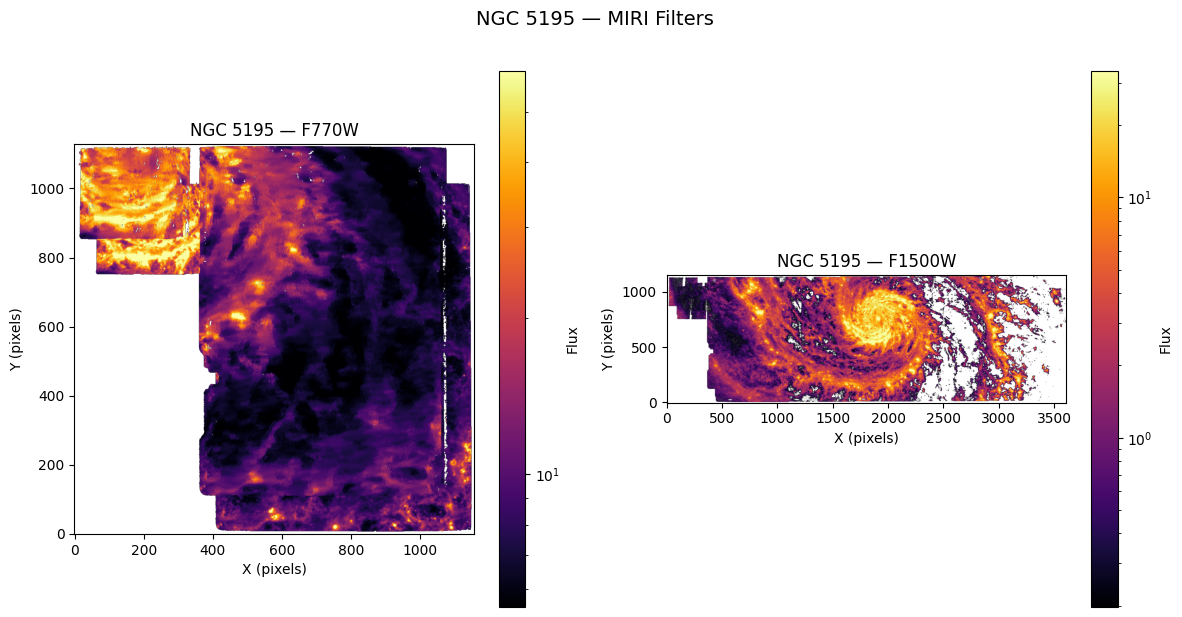

In [ ]:
''' 
The final step this notebook is displaying the filters that were downloaded. This ensures that the correct object was observed and is useful in seeing what the different wavelengths of light can show. It first checks how many filters were downloaded and then defines a subplot for each filter. It will then display a plot with a simple scaling for each filter. 
'''
# Auto-discover local FITS files for plotting
local_fits = {}
for fpath in sorted(glob.glob(os.path.join(f"./fits_images/{target_name}", "*_i2d.fits"))):
    m = _re.search(r"_f(\d+w)", os.path.basename(fpath).lower())
    if m:
        filt = f"F{m.group(1).upper()}"
        if filt in target_filters:
            local_fits[filt] = fpath

found_filters = [f for f in target_filters if f in local_fits]
n_panels = max(len(found_filters), 1)

fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6), squeeze=False)
axes = axes[0]

for i, f in enumerate(found_filters):
    local_path = local_fits[f]
    hdul = fits.open(local_path)

    try:
        cube = hdul['SCI'].data
    except KeyError:
        cube = hdul[1].data

    cube = np.squeeze(cube)

    if cube.ndim == 3:
        image = np.nansum(cube, axis=0)
    elif cube.ndim == 2:
        image = cube
    else:
        print(f"Cannot handle shape {cube.shape} for filter {f}, skipping...")
        hdul.close()
        continue

    image = np.where(image <= 0, np.nan, image)
    vmin = np.nanpercentile(image, 5)
    vmax = np.nanpercentile(image, 99)
    vmin = max(vmin, 1e-10)
    if vmin >= vmax:
        vmax = vmin * 10

    ax = axes[i]
    im = ax.imshow(
        image, origin='lower', cmap='inferno',
        norm=plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)
    )
    ax.set_title(f"{target_name} — {f}", fontsize=12)
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")
    plt.colorbar(im, ax=ax, label="Flux")
    hdul.close()

# Hide unused axes
for j in range(len(found_filters), len(axes)):
    axes[j].set_visible(False)

if not found_filters:
    print(f"No FITS files found for {target_name} with filters {target_filters}")

plt.suptitle(f"{target_name} — MIRI Filters", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()